In [1]:
import sys, os
import numpy as np
from pprint import pprint


ruta_libs = os.path.abspath("../libs")
if ruta_libs not in sys.path:
    sys.path.append(ruta_libs)

from materialLibs import *
from unitsLibs import *
from solveLibs import *
from networkLibs import *

species = ["CO2", "N2"]
WM, mu, Dm, cpg_molar, cpg_mass, k, H = get_properties_gas(species)
prop_gas = {
    "species": species,
    "MW": WM,
    "mu": mu,
    "Dm": Dm,
    "Cp_molar": cpg_molar,
    "Cp_mass": cpg_mass,
    "k": k,
    "H": H}

In [2]:
tank_1 = Tank(
    Name="T1",
    Longitud=2.0,     # m
    Diametro=.61,     # m
    Espesor=0.02,     # m
    prop_gas=prop_gas)

tank_1.initialC_info(P0=3.5e5,T0=298.0,x0=[0.5, 0.5])

tank_1.boundaryC_info(Pin=9e5,Tin=350.0,xin=[0.2, 0.8],Pout=1e5)

tank_1.thermal_info(adi=True,kw=1e99,hint=1e99,hext=1e99,Tamb=298.15)

vT1bi = Valve(
    Name="vT1bi",
    Cv_max= 1.35,  
    valve_type="linear",
    a_min = 0.,
    a_max = 1.,
    logic= "linear",
    logic_params={"start": 1, "duration": 1e-6},
    opening_direction="co")

vT1to = Valve(
    Name="vT1to",
    Cv_max= 1.35,  
    valve_type="linear",
    a_min = 0.,
    a_max = 1.,
    logic= "linear",
    logic_params={"start": 99, "duration": 15},
    opening_direction="co")

tank_2 = Tank(
    Name="T2",
    Longitud=2.0,     # m
    Diametro=.61,     # m
    Espesor=0.02,     # m
    prop_gas=prop_gas)

tank_2.initialC_info(P0=3.5e5,T0=298.0,x0=[0.5, 0.5])

tank_2.boundaryC_info(Pin=9e5,Tin=350.0,xin=[0.2, 0.8],Pout=1e5)

tank_2.thermal_info(adi=True,kw=1e99,hint=1e99,hext=1e99,Tamb=298.15)

vT2bi = Valve(
    Name="vT2bi",
    Cv_max= 1.35,  
    valve_type="linear",
    a_min = 0.,
    a_max = 1.,
    logic= "linear",
    logic_params={"start": 99, "duration": 15},
    opening_direction="co")

vT2to = Valve(
    Name="vT2to",
    Cv_max= 1.35,  
    valve_type="linear",
    a_min = 0.,
    a_max = 1.,
    logic= "linear",
    logic_params={"start": 99, "duration": 15},
    opening_direction="co")

vT1bT2b = Valve(
    Name="vT1bT2b",
    Cv_max= 1.35,  
    valve_type="linear",
    a_min = 0.,
    a_max = 1.,
    logic= "linear",
    logic_params={"start": 99, "duration": 15},
    opening_direction="co")

vT1tT2t = Valve(
    Name="vT1tT2t",
    Cv_max= 1.35,  
    valve_type="linear",
    a_min = 0.,
    a_max = 1.,
    logic= "linear",
    logic_params={"start": 99, "duration": 15},
    opening_direction="co")

valves=[vT1bi,vT1to,vT2bi,vT2to,vT1tT2t,vT1bT2b]
units=[tank_1,tank_2,]

🧠 ProSimNet inicializado 📅 Día: 2025-07-30 ⏰ Hora: 23:12:38
solve_ivp terminado con éxito.
Tiempo simulado: 6.0 s.
Tiempo simulado: 0.29 s.


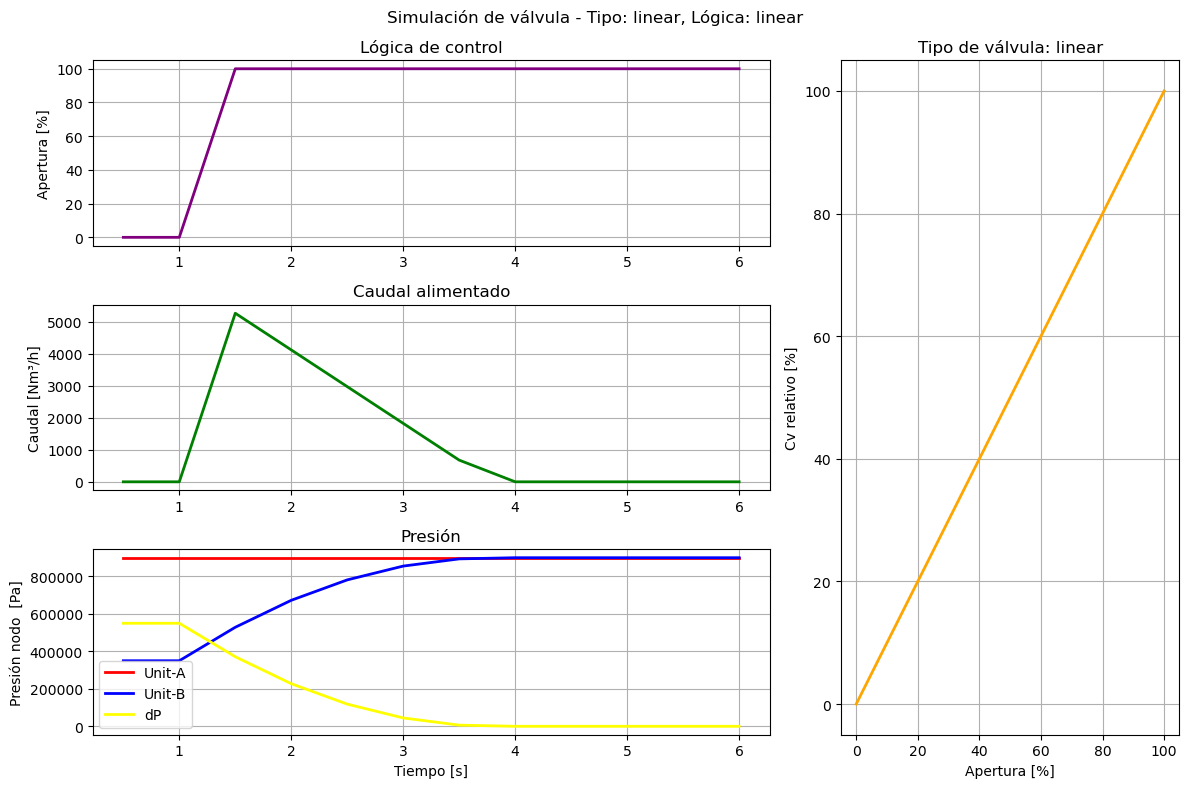

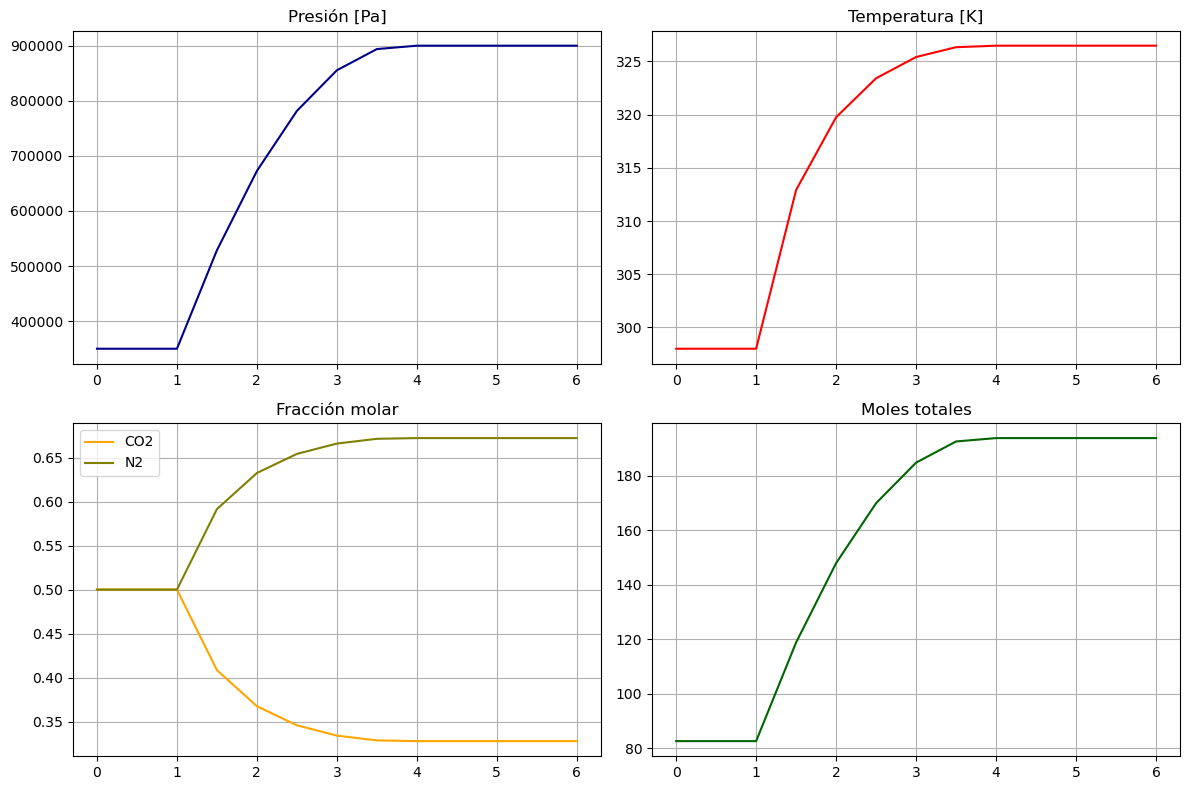

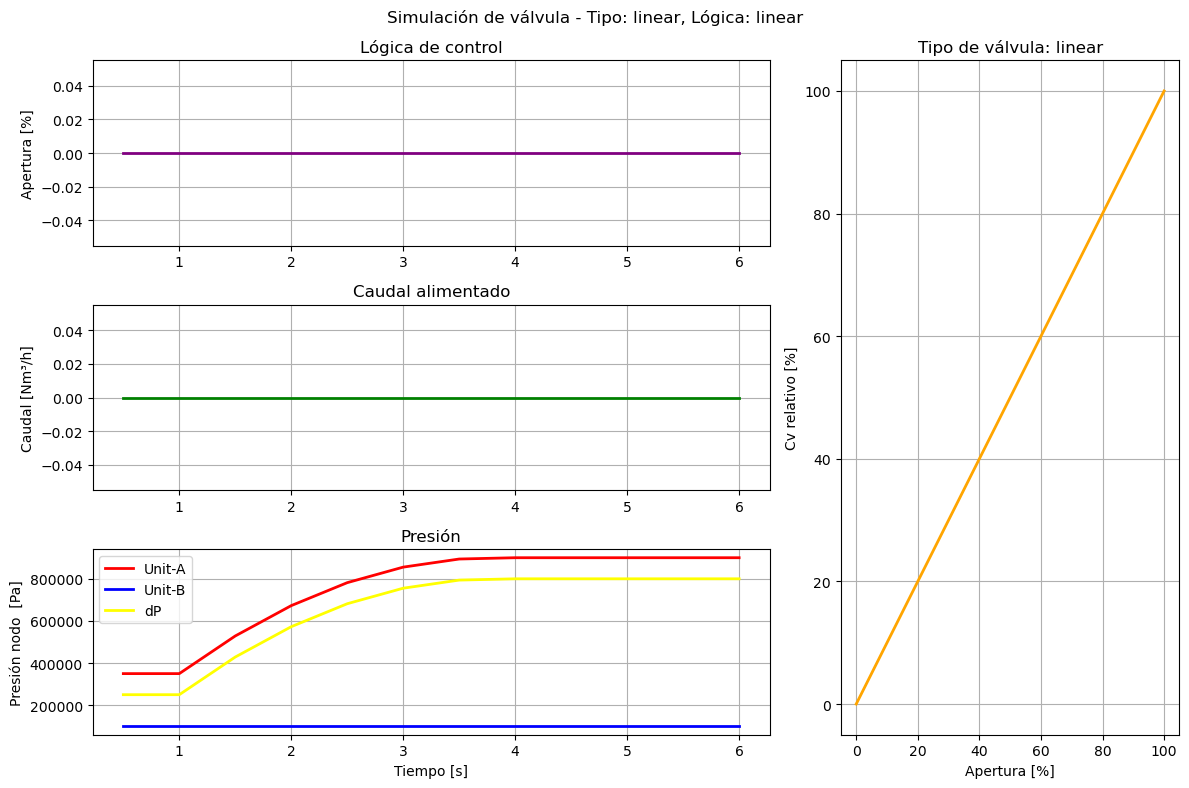

In [3]:
sim=Network(prop_gas=prop_gas,
            Units=units,
            Valves=valves)

sim._updateNetwork()
sim.Run(saveData=0.5,
    startTime=0,
    endTime=6,
    solver='BDF',
    atol=1e-12,
    rtol=1e-12,
    plot=False,
    logBal=False)

sim.Valves[0]._plot()
sim.Units[0]._plot()
sim.Valves[1]._plot()

solve_ivp terminado con éxito.
Tiempo simulado: 6.0 s.
Tiempo simulado: 0.18 s.


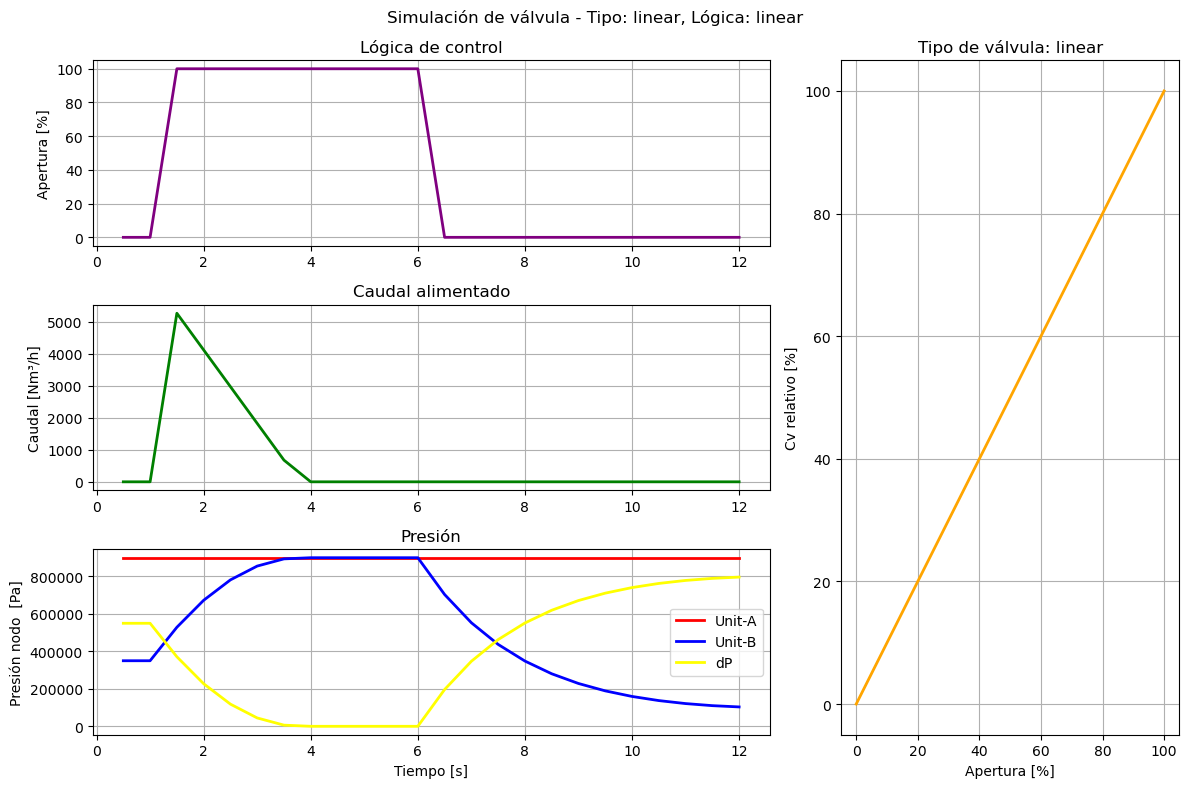

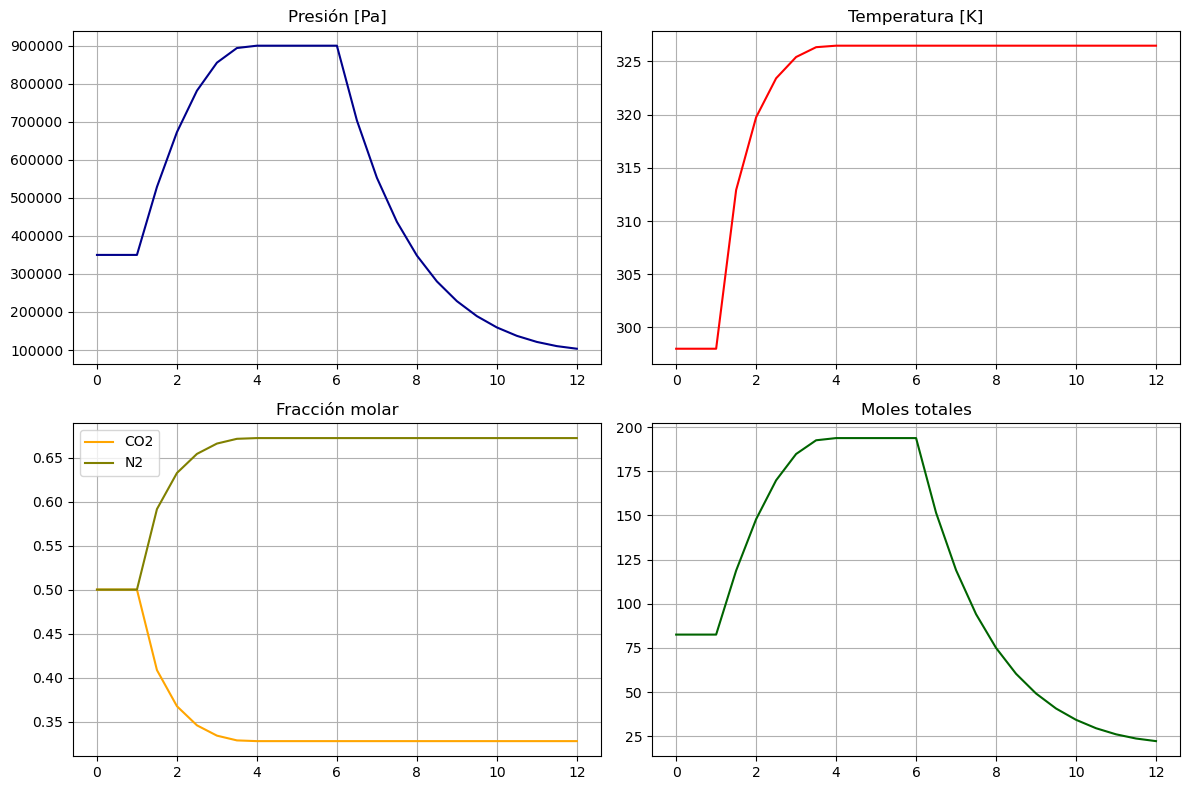

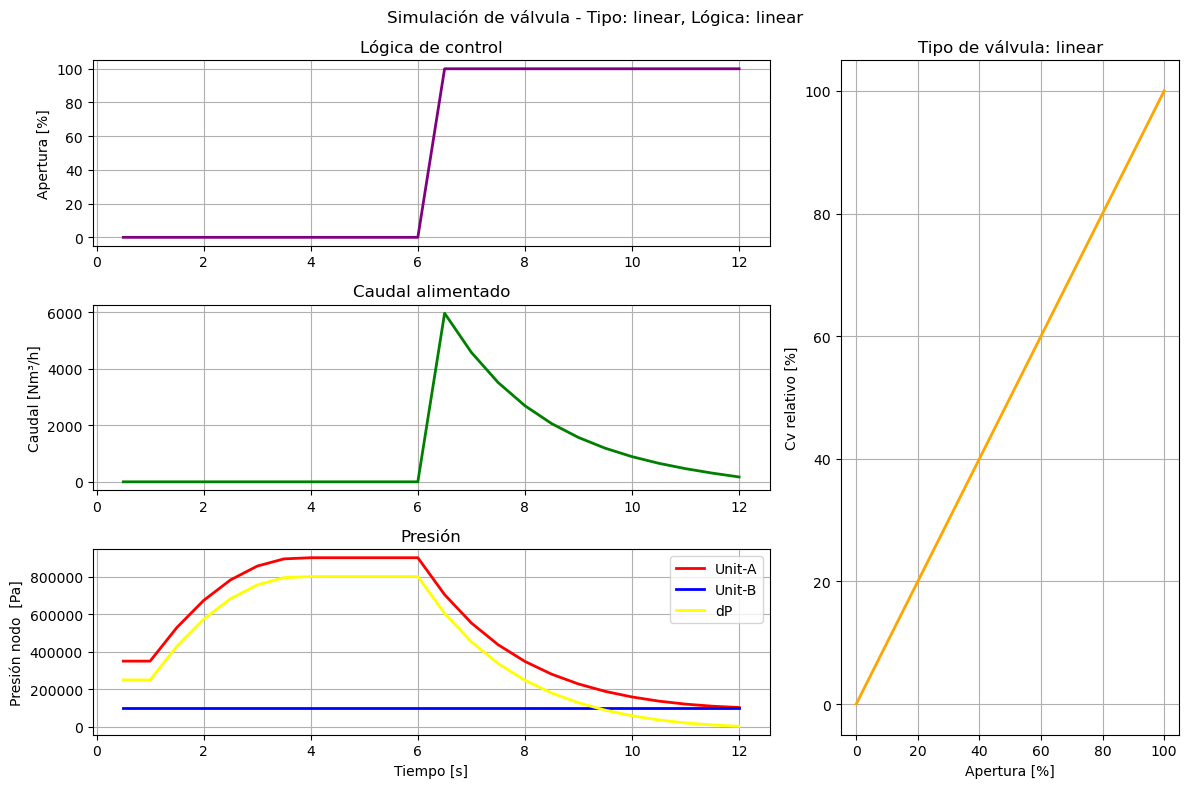

In [4]:
config_vT1bi = {"logic_params": {"start": 6,"duration": 1E-5,},"opening_direction": "oc" }
config_vT1to = {"logic_params": {"start": 6,"duration": 1E-5,},"opening_direction": "co" }

vT1bi.update(config_vT1bi) 
vT1to.update(config_vT1to) 

sim.Run(saveData=0.5,
    startTime='lastTime',
    endTime=12,
    solver='BDF',
    atol=1e-12,
    rtol=1e-12,
    plot=False,
    logBal=False)

sim.Valves[0]._plot()
sim.Units[0]._plot()
sim.Valves[1]._plot()